# ModernBERT Issue Classification Test

Evaluate `QueryClassifier` (ModernBERT zero-shot) on issue-classification datasets in `data/issue_classification`.

This notebook:
- reuses existing project classifier code from `backend/rag/query_classifier.py`,
- supports both dataset JSON schemas,
- reports summary metrics and visualizations,
- optionally exports row-level predictions to CSV.

Run cells top-to-bottom.

In [4]:
# Setup imports and project root
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks" or not (PROJECT_ROOT / "backend").exists():
    PROJECT_ROOT = (PROJECT_ROOT / "..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from backend.rag.query_classifier import QueryClassifier
from backend.config import get_classifier_model, get_classifier_threshold

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: D:\ai_ws\projects\iBud


In [5]:
# Configuration (edit as needed)
DATA_DIR = PROJECT_ROOT / "data" / "issue_classification"

DATASET_CHOICES = {
    "is_issue_test": DATA_DIR / "is_issue_test_dataset.json",
    "david_vs_goliath": DATA_DIR / "david_vs_goliath_is_issue_dataset.json",
}

# Use ["is_issue_test"], ["david_vs_goliath"], or both.
SELECTED_DATASETS = ["david_vs_goliath"]
# SELECTED_DATASETS = ["is_issue_test", "david_vs_goliath"]

# Optional override. Set to None to use env/config defaults.
MODEL_NAME_OVERRIDE = None
THRESHOLD_OVERRIDE = None

# Optional CSV export
SAVE_RESULTS_CSV = False
CSV_OUTPUT_PATH = PROJECT_ROOT / "evaluation" / "results" / "issue_test_predictions.csv"

print("Selected datasets:", SELECTED_DATASETS)
print("Model:", MODEL_NAME_OVERRIDE or get_classifier_model())
print("Threshold:", THRESHOLD_OVERRIDE if THRESHOLD_OVERRIDE is not None else get_classifier_threshold())

Selected datasets: ['david_vs_goliath']
Model: MoritzLaurer/ModernBERT-base-zeroshot-v2.0
Threshold: 0.7


In [6]:
# Dataset loading and normalization

def load_is_issue_test(path: Path) -> pd.DataFrame:
    rows = json.loads(path.read_text(encoding="utf-8"))
    normalized = []
    for row in rows:
        normalized.append(
            {
                "dataset": "is_issue_test",
                "sample_id": row.get("id"),
                "text": str(row.get("user_turn", "")).strip(),
                "expected_is_issue": bool(row.get("is_issue", False)),
                "source_field": "user_turn",
                "notes": row.get("notes"),
            }
        )
    return pd.DataFrame(normalized)


def load_david_vs_goliath(path: Path) -> pd.DataFrame:
    payload = json.loads(path.read_text(encoding="utf-8"))
    rows = payload.get("samples", [])
    normalized = []
    for row in rows:
        normalized.append(
            {
                "dataset": "david_vs_goliath",
                "sample_id": row.get("id"),
                "text": str(row.get("user_message", "")).strip(),
                "expected_is_issue": bool(row.get("is_issue", False)),
                "source_field": "user_message",
                "notes": row.get("notes"),
            }
        )
    return pd.DataFrame(normalized)


def load_selected_datasets(selected: list[str]) -> pd.DataFrame:
    frames = []
    for key in selected:
        path = DATASET_CHOICES[key]
        if not path.exists():
            raise FileNotFoundError(f"Dataset file not found: {path}")

        if key == "is_issue_test":
            frames.append(load_is_issue_test(path))
        elif key == "david_vs_goliath":
            frames.append(load_david_vs_goliath(path))
        else:
            raise ValueError(f"Unknown dataset key: {key}")

    if not frames:
        raise ValueError("No datasets selected.")

    merged = pd.concat(frames, ignore_index=True)
    merged["expected_label"] = np.where(merged["expected_is_issue"], "issue", "not_issue")
    return merged


df_input = load_selected_datasets(SELECTED_DATASETS)
print(f"Loaded {len(df_input)} rows")
df_input.head(5)

Loaded 100 rows


,dataset,sample_id,text,expected_is_issue,source_field,notes,expected_label
0,david_vs_goliath,1,Hi,False,user_message,"Pure greeting, no issue stated",not_issue
1,david_vs_goliath,2,Hello there,False,user_message,Greeting only,not_issue
2,david_vs_goliath,3,Good morning,False,user_message,"Greeting, no request",not_issue
3,david_vs_goliath,4,Hey!,False,user_message,Informal greeting,not_issue
4,david_vs_goliath,5,"Bye, thanks again",False,user_message,"Farewell, conversation closing",not_issue


In [7]:
# Run ModernBERT issue classifier inference
classifier = QueryClassifier(model_name=MODEL_NAME_OVERRIDE, threshold=THRESHOLD_OVERRIDE)

rows = []
for item in df_input.to_dict(orient="records"):
    result = classifier.classify(item["text"])
    pred_is_issue = bool(result.is_issue)
    rows.append(
        {
            **item,
            "predicted_is_issue": pred_is_issue,
            "predicted_label": "issue" if pred_is_issue else "not_issue",
            "confidence": float(result.confidence),
            "model_top_label": str(result.label),
            "is_correct": pred_is_issue == item["expected_is_issue"],
        }
    )

results_df = pd.DataFrame(rows)
print("Inference complete")
print("Total rows:", len(results_df))
results_df.head(5)

d:\ai_ws\projects\iBud\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The `reference_compile` argument is deprecated and will be removed in `transformers v5.2.0`Use `torch.compile()` directly on the model instead.
Loading weights: 100%|██████████| 138/138 [00:00<00:00, 1310.10it/s, Materializing param=model.layers.21.mlp_norm.weight]    


Inference complete
Total rows: 100


,dataset,sample_id,text,expected_is_issue,source_field,notes,expected_label,predicted_is_issue,predicted_label,confidence,model_top_label,is_correct
0,david_vs_goliath,1,Hi,False,user_message,"Pure greeting, no issue stated",not_issue,False,not_issue,0.592667,general information request,True
1,david_vs_goliath,2,Hello there,False,user_message,Greeting only,not_issue,False,not_issue,0.661923,general information request,True
2,david_vs_goliath,3,Good morning,False,user_message,"Greeting, no request",not_issue,False,not_issue,0.558327,customer issue or complaint,True
3,david_vs_goliath,4,Hey!,False,user_message,Informal greeting,not_issue,False,not_issue,0.640636,customer issue or complaint,True
4,david_vs_goliath,5,"Bye, thanks again",False,user_message,"Farewell, conversation closing",not_issue,True,issue,0.731059,customer issue or complaint,False


In [8]:
# Metrics and tabular summaries

def compute_binary_metrics(frame: pd.DataFrame) -> dict:
    y_true = frame["expected_is_issue"].astype(bool).to_numpy()
    y_pred = frame["predicted_is_issue"].astype(bool).to_numpy()

    tp = int(np.sum((y_true == True) & (y_pred == True)))
    tn = int(np.sum((y_true == False) & (y_pred == False)))
    fp = int(np.sum((y_true == False) & (y_pred == True)))
    fn = int(np.sum((y_true == True) & (y_pred == False)))
    total = len(frame)

    accuracy = (tp + tn) / total if total else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0.0

    return {
        "count": total,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }


def metrics_table(frame: pd.DataFrame) -> pd.DataFrame:
    groups = {"overall": frame}
    for ds_name in sorted(frame["dataset"].unique()):
        groups[f"dataset:{ds_name}"] = frame[frame["dataset"] == ds_name]

    rows = []
    for scope, scope_df in groups.items():
        m = compute_binary_metrics(scope_df)
        rows.append(
            {
                "scope": scope,
                "count": m["count"],
                "accuracy": m["accuracy"],
                "precision": m["precision"],
                "recall": m["recall"],
                "f1": m["f1"],
                "tp": m["tp"],
                "tn": m["tn"],
                "fp": m["fp"],
                "fn": m["fn"],
            }
        )

    return pd.DataFrame(rows)


summary_df = metrics_table(results_df)
summary_df

,scope,count,accuracy,precision,recall,f1,tp,tn,fp,fn
0,overall,100,0.73,0.828571,0.58,0.682353,29,44,6,21
1,dataset:david_vs_goliath,100,0.73,0.828571,0.58,0.682353,29,44,6,21


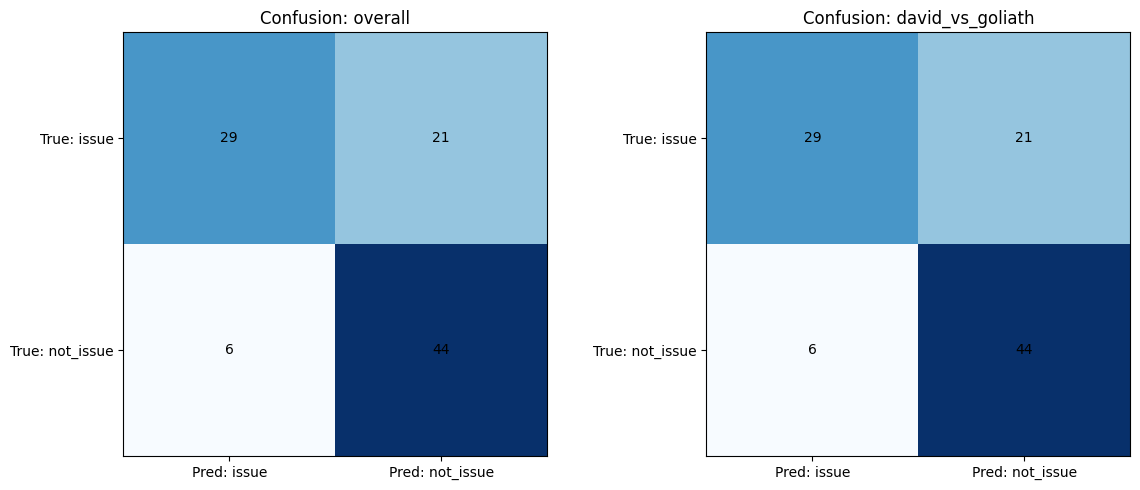

In [9]:
# Confusion matrix visualization

def confusion_counts(frame: pd.DataFrame) -> np.ndarray:
    tp = int(np.sum((frame["expected_is_issue"] == True) & (frame["predicted_is_issue"] == True)))
    fn = int(np.sum((frame["expected_is_issue"] == True) & (frame["predicted_is_issue"] == False)))
    fp = int(np.sum((frame["expected_is_issue"] == False) & (frame["predicted_is_issue"] == True)))
    tn = int(np.sum((frame["expected_is_issue"] == False) & (frame["predicted_is_issue"] == False)))
    # rows=true label [issue, not_issue], cols=pred label [issue, not_issue]
    return np.array([[tp, fn], [fp, tn]], dtype=int)


def plot_confusion(ax, frame: pd.DataFrame, title: str) -> None:
    cm = confusion_counts(frame)
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1], ["Pred: issue", "Pred: not_issue"])
    ax.set_yticks([0, 1], ["True: issue", "True: not_issue"])
    ax.set_title(title)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")


names = ["overall"] + sorted(results_df["dataset"].unique())
fig, axes = plt.subplots(1, len(names), figsize=(6 * len(names), 5))
if len(names) == 1:
    axes = [axes]

for ax, name in zip(axes, names):
    if name == "overall":
        scope_df = results_df
    else:
        scope_df = results_df[results_df["dataset"] == name]
    plot_confusion(ax, scope_df, f"Confusion: {name}")

plt.tight_layout()
plt.show()

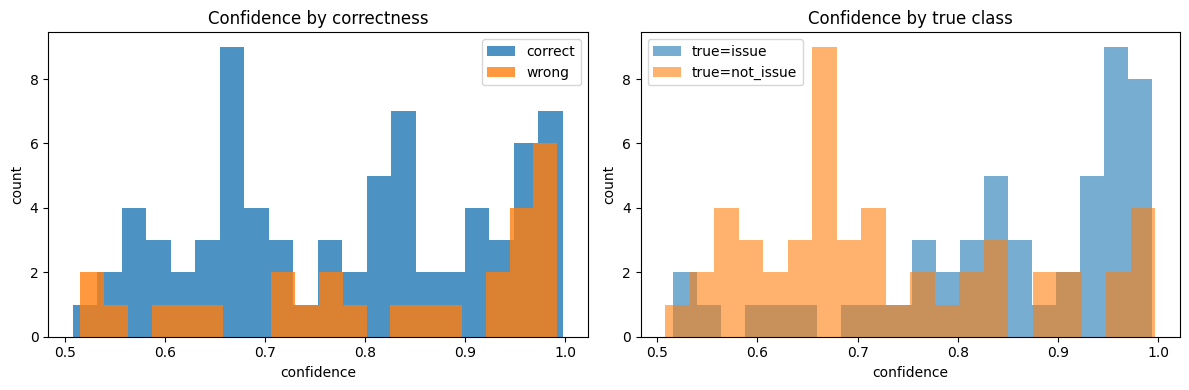

In [10]:
# Confidence visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

correct_conf = results_df.loc[results_df["is_correct"], "confidence"]
wrong_conf = results_df.loc[~results_df["is_correct"], "confidence"]
axes[0].hist(correct_conf, bins=20, alpha=0.8, label="correct")
axes[0].hist(wrong_conf, bins=20, alpha=0.8, label="wrong")
axes[0].set_title("Confidence by correctness")
axes[0].set_xlabel("confidence")
axes[0].set_ylabel("count")
axes[0].legend()

for expected, color in [(True, "tab:blue"), (False, "tab:orange")]:
    vals = results_df.loc[results_df["expected_is_issue"] == expected, "confidence"]
    label = "true=issue" if expected else "true=not_issue"
    axes[1].hist(vals, bins=20, alpha=0.6, label=label, color=color)
axes[1].set_title("Confidence by true class")
axes[1].set_xlabel("confidence")
axes[1].set_ylabel("count")
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# Result summary and error analysis
overall = summary_df.loc[summary_df["scope"] == "overall"].iloc[0]
print(
    "Overall metrics | "
    f"accuracy={overall['accuracy']:.4f}, "
    f"precision={overall['precision']:.4f}, "
    f"recall={overall['recall']:.4f}, "
    f"f1={overall['f1']:.4f}, "
    f"count={int(overall['count'])}"
)

print("\nPer-dataset metrics:")
display(summary_df)

mistakes = results_df[~results_df["is_correct"]].copy()
if mistakes.empty:
    print("\nNo misclassifications found.")
else:
    mistakes = mistakes.sort_values(by="confidence", ascending=False)
    print(f"\nTop {min(20, len(mistakes))} misclassifications by confidence:")
    display(
        mistakes[
            [
                "dataset",
                "sample_id",
                "text",
                "expected_label",
                "predicted_label",
                "confidence",
                "model_top_label",
                "notes",
            ]
        ].head(20)
    )

Overall metrics | accuracy=0.7300, precision=0.8286, recall=0.5800, f1=0.6824, count=100

Per-dataset metrics:


,scope,count,accuracy,precision,recall,f1,tp,tn,fp,fn
0,overall,100,0.73,0.828571,0.58,0.682353,29,44,6,21
1,dataset:david_vs_goliath,100,0.73,0.828571,0.58,0.682353,29,44,6,21



Top 20 misclassifications by confidence:


,dataset,sample_id,text,expected_label,predicted_label,confidence,model_top_label,notes
8,david_vs_goliath,9,Not helpful at all,not_issue,issue,0.991748,customer issue or complaint,"Negative sentiment, no new information for ret..."
76,david_vs_goliath,77,Can you tell me what data you store about end ...,issue,not_issue,0.989098,general information request,Informational data privacy question with busin...
60,david_vs_goliath,61,What's the difference between the Business and...,issue,not_issue,0.985936,general information request,"Pre-purchase informational question, answerable"
73,david_vs_goliath,74,We want to migrate all our data to a new accou...,issue,not_issue,0.979511,general information request,Account management question requiring procedur...
85,david_vs_goliath,86,Do you offer HIPAA-compliant data processing? ...,issue,not_issue,0.978364,general information request,Compliance qualification question with industr...
46,david_vs_goliath,47,"Never mind, ignore that last message",not_issue,issue,0.971886,customer issue or complaint,Request explicitly withdrawn
9,david_vs_goliath,10,WTF,not_issue,issue,0.967472,customer issue or complaint,"Expressive frustration, no actionable issue co..."
64,david_vs_goliath,65,My reports are showing data from last month ev...,issue,not_issue,0.959154,general information request,UI bug with clear reproduction step
94,david_vs_goliath,95,I want to understand how your AI decides which...,issue,not_issue,0.952397,general information request,Documentation/explainability question with cle...
69,david_vs_goliath,70,Is it possible to restrict which IP addresses ...,issue,not_issue,0.950411,general information request,Feature availability question relevant to secu...


In [12]:
# Optional CSV export
if SAVE_RESULTS_CSV:
    CSV_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    results_df.to_csv(CSV_OUTPUT_PATH, index=False)
    print(f"Saved predictions to: {CSV_OUTPUT_PATH}")
else:
    print("CSV export disabled. Set SAVE_RESULTS_CSV = True to save output.")

CSV export disabled. Set SAVE_RESULTS_CSV = True to save output.


## Notes

- `predicted_is_issue` is produced by `QueryClassifier.classify`, including its confidence threshold behavior.
- To test alternate checkpoints or thresholds, update `MODEL_NAME_OVERRIDE` / `THRESHOLD_OVERRIDE` and rerun from the inference cell.
- For reproducible comparisons, keep `SELECTED_DATASETS` and threshold fixed across runs.